In [1]:
import sys
sys.path.append('/Users/mariana/Documents/col/lts4/survan')
sys.path.append('/Users/mariana/Documents/col/lts4/tdsurv/lib')



from deep_lambda_cox import DeepLambdaSA

from utils import concordance_index, unroll_time, unroll, score
import yaml
import jax
import jax.numpy as jnp
import haiku as hk
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from scipy.special import expit as sigmoid
from utils import get_targets_and_masks
import pickle

In [3]:
# Borrowed from tdsurv (https://github.com/spotify-research/tdsurv/blob/main/notebooks/random-walk-final.ipynb)
def make_generator(mat, sigma, sigma0, thetas, bias, rng):
    """Sample from a Gauss-Markov process.
    
    Initial state:
    
        x_0 = noise(sigma0)
    
    Transition dynamics:
    
        x_nxt = np.dot(mat, x) + noise(sigma)
        
    Churn probability:
    
        p = sigmoid(np.dot(x, thetas) + bias)
    """
    n_dims = mat.shape[0]
    def gen(n_samples, horizon):
        seqs = np.zeros((n_samples, horizon + 1, n_dims + 1))
        ts = np.zeros(n_samples, dtype=int)
        cs = np.zeros(n_samples, dtype=bool)
        for i in range(n_samples):
            seqs[i, 0] = np.append(sigma0 * rng.normal(size=n_dims), 1)
            ts[i] = 1
            for j in range(0, horizon):
                p = sigmoid(np.dot(seqs[i, j, :-1], thetas) + bias)
                if rng.uniform() < p:
                    break
                ts[i] += 1
                seqs[i, j + 1] = np.append(
                    np.dot(mat, seqs[i, j, :-1]) + sigma * rng.normal(size=n_dims),
                    1,
                )
            if ts[i] > horizon:
                ts[i] = horizon
                cs[i] = True
        tgt_lm, hws_lm, mask_lm = get_targets_and_masks(seqs, ts, cs, landmark=True)
        return (seqs.astype(np.float32), ts, cs, tgt_lm, hws_lm, mask_lm)
    return gen

In [15]:
rng = np.random.default_rng(seed=0)

n_dims = 20
horizon = 100
d = n_dims + 1
H = horizon + 1

# Churn parameters.
thetas = rng.normal(size=n_dims)
bias = -10

# Transition dynamics.
mat = 1.0 * np.eye(n_dims)
sigma = 0.5
sigma0 = 1.0 # Affect results quite a lot


gen = make_generator(mat, sigma, sigma0, thetas, bias, rng)
seqs, ts, cs, y, hws, m = gen(n_samples=1000, horizon=horizon)

# rng = np.random.default_rng(seed=42)
# gen = make_generator(mat, sigma, sigma0, thetas, bias, rng)
# seqs_v, ts_v, cs_v, y_v, hws_v, m_v = gen(n_samples=2000, horizon=horizon)

In [16]:
ts

array([ 20,  25, 100,   3, 100, 100, 100,  12,  28, 100,  12,  20,  11,
        54, 100,  27, 100,  15,   9,  34, 100, 100,  68,  22, 100, 100,
        21, 100, 100,  55,  17, 100, 100,  41,  35, 100,  71, 100,   4,
       100,  17,  10, 100,  34, 100, 100,  16,  75, 100, 100, 100,   5,
        44,   5,  18, 100,  83,  23,  67, 100,  25, 100, 100,  85, 100,
        59,  12,  10,  58,  21,  35, 100,   6, 100, 100,  73,  85, 100,
        82, 100,  11,   8,  15, 100,  24,  17,  28,  19,   7,  20, 100,
       100,   8,   4,  37,  26,  48,  62,   7,  59, 100, 100,  50,  20,
        30,  33,  16,  16, 100,   1,  39,  52,  27,  11,  31,  47, 100,
       100, 100,  37, 100, 100,  14, 100,  19,  93, 100,   9,  49,  66,
        20,   6,  39,  24,   7,  29,  47, 100, 100,  76,  19, 100,  42,
        19, 100,   5, 100, 100,  65,   3, 100, 100,  30,  19,  19, 100,
        73, 100, 100, 100, 100,   8,  10,  26, 100,  39,   6,  39,  12,
       100,  28, 100, 100,  30,  20, 100,  14,  42,  65, 100, 10

In [17]:
cs.sum()/cs.shape[0]

0.368

In [18]:
import pickle

In [20]:
# Load dataset from "../../SurvanData/bigrw-seqs.pkl"
with open("/Users/mariana/Documents/col/lts4/SurvanData/bigrw-seqs-hard.pkl", "rb") as f:
    data = pickle.load(f)

seqs = data["seqs"]

FileNotFoundError: [Errno 2] No such file or directory: '/Users/mariana/Documents/col/lts4/SurvanData/bigrw-seqs-hard.pkl'

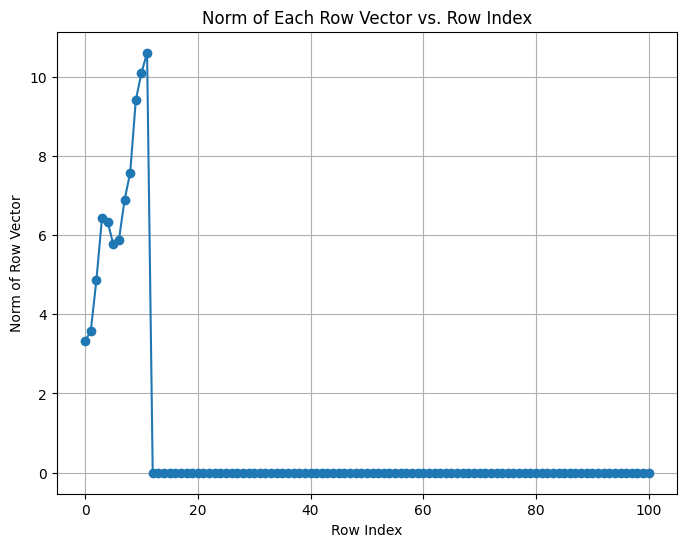

In [21]:
norms = jnp.linalg.norm(seqs[10], axis=1)

# Create a plot of the norm values vs. the row indices
plt.figure(figsize=(8, 6))
plt.plot(norms, marker='o', linestyle='-')
plt.xlabel('Row Index')
plt.ylabel('Norm of Row Vector')
plt.title('Norm of Each Row Vector vs. Row Index')
plt.grid(True)
plt.show()

In [7]:
seqs.shape

(10000, 100, 50)

In [8]:
# with open("../../SurvanData/bigrw-seqs.pkl", "wb") as f:
#     pickle.dump({
#         "seqs": seqs,
#         "cs": cs,
#         "ts": ts,
#         "target": y,
#         "h_ws": hws,
#         "mask": m
#     }, f)

In [2]:
config_path = '../configs/config_bigrw.yaml'
config = yaml.load(open(config_path, 'r'), Loader=yaml.FullLoader)

NameError: name 'yaml' is not defined

In [10]:
seqs.shape

(1000, 11, 21)

In [24]:
# config['landmark'] = True
config['num_epochs'] = 50
config['lambda_'] = 0.0
config['target_lr'] = 0.01
# model = SA(config, seed=1)
model = DeepLambdaSA(config, seed=2)

In [12]:
size = 800

In [13]:
train_gen, test_gen = model.get_train_test()

train_gen.X = seqs[:size]
train_gen.ts = ts[:size]
train_gen.cs = cs[:size]
train_gen.y = y[:size]
train_gen.mask = m[:size]
train_gen.h_ws = hws[:size]

In [14]:
model.data['seqs'].shape

(10000, 100, 50)

In [15]:
train_gen, test_gen = model.get_train_test(test_size=.8)
loss = model.train(train_gen)

100%|██████████| 50/50 [01:16<00:00,  1.54s/it]


In [16]:
-1e4

-10000.0

In [17]:
loss

[0.008956846781075,
 0.007679260801523924,
 0.005715788342058659,
 0.005348695907741785,
 0.0060629090294241905,
 0.0062354071997106075,
 0.006641761399805546,
 0.006006612442433834,
 0.006515675224363804,
 0.00700816186144948,
 0.006625523790717125,
 0.0054258625023067,
 0.005965485703200102,
 0.005572664085775614,
 0.007321828044950962,
 0.008273208513855934,
 0.0069480468519032,
 0.007111389189958572,
 0.005624157376587391,
 0.007746969349682331,
 0.006573962979018688,
 0.006388500798493624,
 0.007330581545829773,
 0.006367098074406385,
 0.007355582434684038,
 0.005849678535014391,
 0.0071067288517951965,
 0.006610264535993338,
 0.0067406995221972466,
 0.005996088031679392,
 0.007822444662451744,
 0.006946365348994732,
 0.006893342360854149,
 0.006721276789903641,
 0.006766832433640957,
 0.00704047130420804,
 0.007355324923992157,
 0.007771399337798357,
 0.007992311380803585,
 0.007949686609208584,
 0.007178898435086012,
 0.005541080608963966,
 0.007352064363658428,
 0.0071528041735

In [18]:
# model.config.num_epochs = 100
# loss = model.train(train_gen)

In [19]:
train_gen.X.shape

(2000, 100, 50)

In [20]:
train_gen.ts.sum()

71885

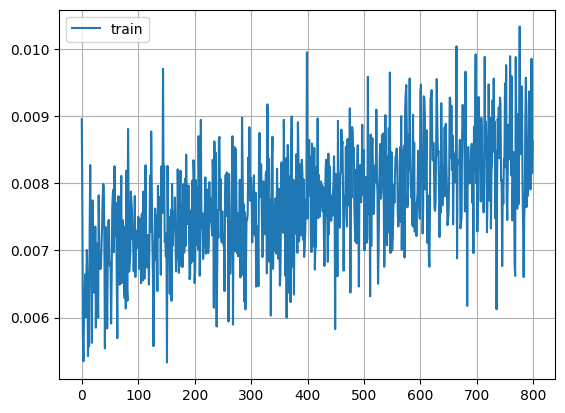

In [21]:
plt.plot(loss, label='train')
# plt.plot(loss[1], label='test')
plt.legend()
plt.grid()

In [25]:
seqs = train_gen.X
ts = train_gen.ts
cs = train_gen.cs
y = train_gen.y

scores = model.scores(seqs, q=0.0)
concordance_index(scores, ts, cs)

0.5562084002754188

In [23]:
model.state.params['linear']['b'].sum()

Array(-16.120478, dtype=float32)

In [21]:
seqs.sum()

-15366.978

In [24]:
model.state.params

{'linear': {'b': Array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
         nan, nan, nan, nan, nan, nan, nan, nan, nan], dtype=float32),
  'w': Array([[nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         ...,
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan],
         [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)},
 'ts_transformer/layer_norm': {'offset': Array([nan, nan, nan, nan, nan, nan, nan, 

In [194]:
seqs_t = test_gen.X
ts_t = test_gen.ts
cs_t = test_gen.cs
y_t = test_gen.y

scores = model.scores(seqs_t, q=0.0)
concordance_index(scores, ts_t, cs_t)

0.7770200796435441

In [14]:
ts.max()

99

In [93]:
cs.sum()/len(cs)

0.182

In [195]:
100 + 7.95 + 14.85 + 14

136.8